# Array Efficiency Analysis for 2025

**Author:** Marwan Negm

**Date:** 2026-1-06

**Relevant Links:**
- [Monday Post](https://ubcsolar26.monday.com/boards/9565353662/pulses/9773052619)
- [DR0](https://docs.google.com/document/d/19uLX7iUFfbZED2y24udkK1MQrO5hOUxp5Yb9y1QJywU/edit?usp=sharing)
- The following code is mostly taken from 2024 efficiency analysis, but updated for 2025


## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [1]:
import scripts.openmeteo_request_functions as opf 
from data_tools import TimeSeries, DBClient
from datetime import datetime, timedelta
import pytz
import matplotlib.pyplot as plt
import numpy as np
import pvlib
from scipy.signal import butter, filtfilt

## Data Acquisition

Obtain the data relevant to this analysis. Load data from saved files, or query it directly.

In [3]:
latitude = 37.002923
longitude = -86.3686424
start_date = "2025-07-01"
end_date = "2025-07-03"
total_surface_area = 4

location = pvlib.location.Location(latitude, longitude, tz='America/Chicago', altitude=None, name=None)

def get_string_power(start: datetime, end: datetime, array_string: str, current_name: str, volt_name: str, client: DBClient) -> TimeSeries:
    print(f"{current_name}{array_string}")
    print(f"{volt_name}{array_string}")
    current:TimeSeries = client.query_time_series(start, end, f"{current_name}{array_string}")
    voltage:TimeSeries = client.query_time_series(start, end, f"{volt_name}{array_string}")
    current, voltage = TimeSeries.align(current, voltage)
    power = current.promote(current * voltage)
    return power

def get_total_power(start: datetime, end: datetime, array_strings: list[str], current_name: str, volt_name: str, client: DBClient = None) -> TimeSeries:
    if client == None: client = DBClient(url="100.120.214.69:8086")

    total_power = None

    for array_string in array_strings:
        power_in_string:TimeSeries = get_string_power(start, end, array_string, current_name, volt_name, client)

        if total_power is None:
            total_power:TimeSeries = power_in_string
        else:
            total_power, power_in_string = TimeSeries.align(total_power, power_in_string)
            total_power = total_power.promote(power_in_string + total_power)

    return total_power

irradiance_series = opf.open_meteo_archive_timeseries(latitude, longitude, start_date, end_date, "terrestrial_radiation_instant", "GMT")
time_series = irradiance_series.datetime_x_axis

start_time: datetime = time_series[0]
end_time: datetime = time_series[-1]

start_time = pytz.timezone('UTC').localize(start_time) 
end_time = pytz.timezone('UTC').localize(end_time)

print(f"Start time is {start_time}; End time is {end_time}")

total_power_series = get_total_power(start_time, end_time, ["A", "B", "C"], "InputCurrent", "InputVoltage")





Coordinates 37.01230239868164°N -86.31924438476562°E
Timezone None None
Timezone difference to GMT+0 0 s
Start time is 2025-07-01 07:00:00+00:00; End time is 2025-07-04 07:00:00+00:00
InputCurrentA
InputVoltageA
InputCurrentB
InputVoltageB
InputCurrentC
InputVoltageC


## Analysis

Compute the desired results and present them. Take advantage of Markdown cells to guide the reader through your derivation process.

In [4]:
shifted_power_series = total_power_series.copy()

shifted_power_series._start = total_power_series._start + timedelta(hours=(7)) #Time has to be shifted by 7 hours because Influx takes in UTC 
shifted_power_series._stop = total_power_series._stop + timedelta(hours=(7))

irradiance_series, shifted_power_series = TimeSeries.align(irradiance_series, shifted_power_series)

date_time_x_axis = shifted_power_series.datetime_x_axis

new_irradiance_series = location.get_clearsky(date_time_x_axis)

print(new_irradiance_series)


                                      ghi         dni        dhi
2025-07-01 11:59:00.565999985  164.273876  373.828225  64.283285
2025-07-01 11:59:00.665999889  164.279153  373.836002  64.284494
2025-07-01 11:59:00.766000032  164.284432  373.843783  64.285704
2025-07-01 11:59:00.865999937  164.289708  373.851560  64.286913
2025-07-01 11:59:00.966000080  164.294987  373.859341  64.288123
...                                   ...         ...        ...
2025-07-04 06:59:58.967999935    0.000000    0.000000   0.000000
2025-07-04 06:59:59.068000078    0.000000    0.000000   0.000000
2025-07-04 06:59:59.167999983    0.000000    0.000000   0.000000
2025-07-04 06:59:59.268000126    0.000000    0.000000   0.000000
2025-07-04 06:59:59.368000031    0.000000    0.000000   0.000000

[2412589 rows x 3 columns]


[0.37641225 2.47081591 4.45708057 ... 0.00447719 0.00448098 0.00448478]
[ 0.00000000e+00  4.14492477e-06  8.28984955e-06 ... -1.24347743e-05
 -8.28984955e-06 -4.14492477e-06]
[85477760.9486642   6099701.77227455 26330263.93161114 ...
 54810820.65402368 26330263.93161115  6099701.77227455]
0.10000000082900427
2412589


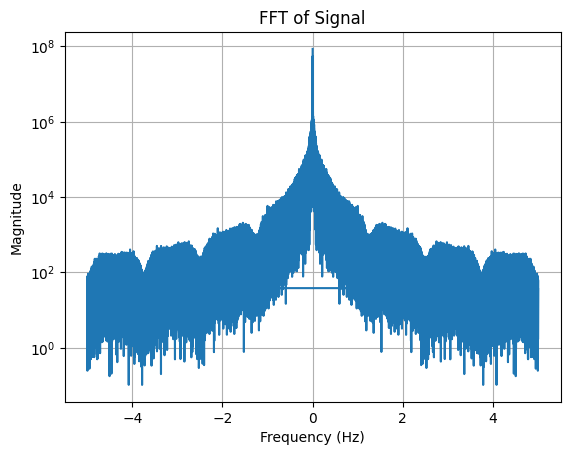

In [5]:

N = len(shifted_power_series)  # Number of data points
sampling_rate = 1/shifted_power_series._period  # Sampling rate (in Hz)
# Perform FFT
fft_result = np.fft.fft(shifted_power_series)
# Frequency axis (for single-sided spectrum)
frequencies = np.fft.fftfreq(N, d=shifted_power_series._period)  # Positive frequencies only
fft_magnitude = np.abs(fft_result)  # Magnitude of the FFT (single-sided)

print(shifted_power_series)
print(frequencies)
print(fft_magnitude)
print(shifted_power_series._period)
print(len(shifted_power_series))

# Plot the FFT
plt.plot(frequencies, fft_magnitude)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Signal')
plt.yscale('log')
plt.grid(True)
plt.show()

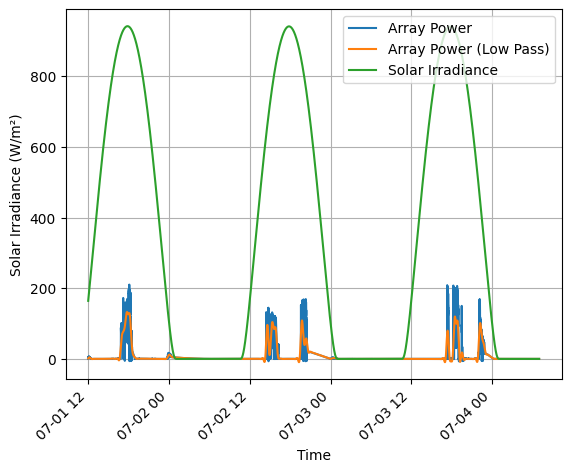

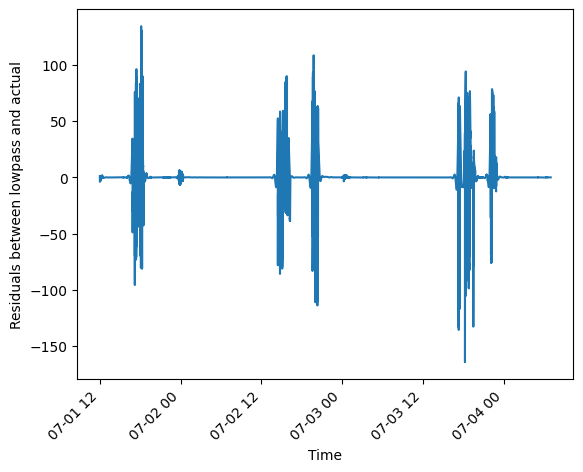

In [6]:

# Filter parameters
cutoff_freq = 1  # Cutoff frequency in Hz
fs = 20000  # Sampling rate in Hz
order = 4  # Filter order

# Design the low-pass filter
nyq = 0.5 * fs
normal_cutoff = cutoff_freq / nyq
b, a = butter(order, normal_cutoff, btype='lowpass')

filtered_power_series = filtfilt(b, a, shifted_power_series)

# Graph of the power series
plt.plot(date_time_x_axis, shifted_power_series/total_surface_area, label = 'Array Power') # The arrays were 4 m², this calculates power/m²
plt.plot(date_time_x_axis, filtered_power_series/total_surface_area, label = 'Array Power (Low Pass)')
#plt.plot(date_time_x_axis, irradiance_series)
plt.plot(date_time_x_axis, new_irradiance_series['ghi'], label = 'Solar Irradiance')

plt.xticks(rotation = 45, ha='right')

plt.grid()

plt.legend(loc = 'upper right')

plt.ylabel("Solar Irradiance (W/m²)")
plt.xlabel("Time")

plt.show()

# Graph of residuals
plt.plot(date_time_x_axis, (filtered_power_series - shifted_power_series)/total_surface_area)
plt.xticks(rotation = 45, ha='right')
plt.ylabel("Residuals between lowpass and actual")
plt.xlabel("Time")
plt.show()



average efficiency is 0.09354931845124363
Peak efficiency is 0.14096687422714124


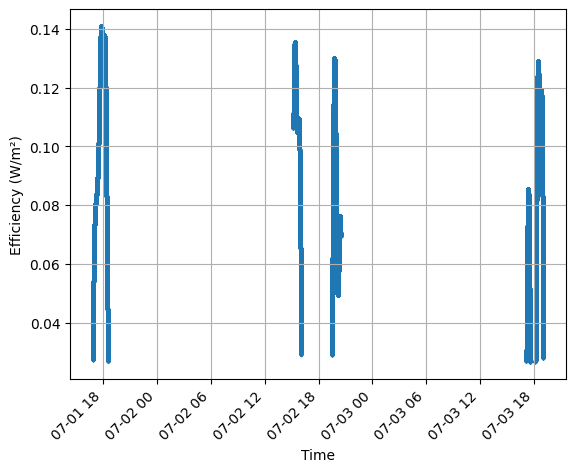

Text(0.5, 0, 'Solar Irradiance (W/m²)')

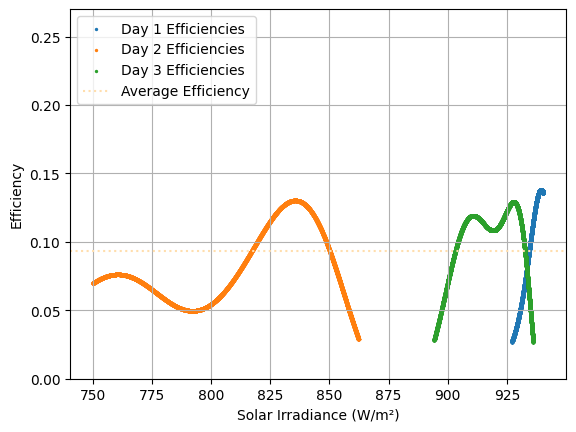

In [ ]:
mask = new_irradiance_series['ghi'] > 750

# Day masks
mask1 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(2025, 7, 1, 18)), date_time_x_axis < datetime(2025, 7, 2, 12))
mask2 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(2025, 7, 2, 18)), date_time_x_axis < datetime(2025, 7, 3, 12))
mask3 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(2025, 7, 3 , 18)), date_time_x_axis < datetime(2025, 7, 4, 12))

mask_without_day_2 = np.logical_or(mask1, mask3)

#Filter both the x and y data using the mask
x_filtered = date_time_x_axis[mask]
y_filtered = (filtered_power_series[mask] / total_surface_area) / new_irradiance_series['ghi'][mask]

y_filtered_without_day_2 = (filtered_power_series[mask_without_day_2] / total_surface_area) / new_irradiance_series['ghi'][mask_without_day_2]

average_efficiency = np.mean(y_filtered)
peak_efficiency = np.max(y_filtered)
#average_efficiency_without_day_2 =  np.mean(y_filtered_without_day_2)
print(f"average efficiency is {average_efficiency}")
#print(f"average efficiency without day 2 is {average_efficiency_without_day_2}")
print(f"Peak efficiency is {peak_efficiency}")

#Plot the filtered data
plt.scatter(x_filtered, y_filtered, s=2)
plt.grid()

plt.ylabel("Efficiency (W/m²)")
plt.xlabel("Time")

plt.xticks(rotation = 45, ha='right')

plt.show()

#Plotting efficiency by day, serves as good evidence that the data of day 2 is strange
plt.scatter(new_irradiance_series['ghi'][mask1], (filtered_power_series[mask1] / total_surface_area) / new_irradiance_series['ghi'][mask1], s=2, label = 'Day 1 Efficiencies')
plt.scatter(new_irradiance_series['ghi'][mask2], (filtered_power_series[mask2] / total_surface_area) / new_irradiance_series['ghi'][mask2], s=2, label = 'Day 2 Efficiencies')
plt.scatter(new_irradiance_series['ghi'][mask3], (filtered_power_series[mask3] / total_surface_area) / new_irradiance_series['ghi'][mask3], s=2, label = 'Day 3 Efficiencies')

plt.axhline(average_efficiency, label='Average Efficiency', ls = ':', color = 'navajowhite')
#plt.axhline(average_efficiency_without_day_2, label='Average Efficiency (Day 2 excluded)', ls = ':', color = 'lightseagreen')

plt.legend(loc = 'upper left')
plt.grid()
plt.ylim(0, 0.27)

plt.ylabel("Efficiency")
plt.xlabel("Solar Irradiance (W/m²)")


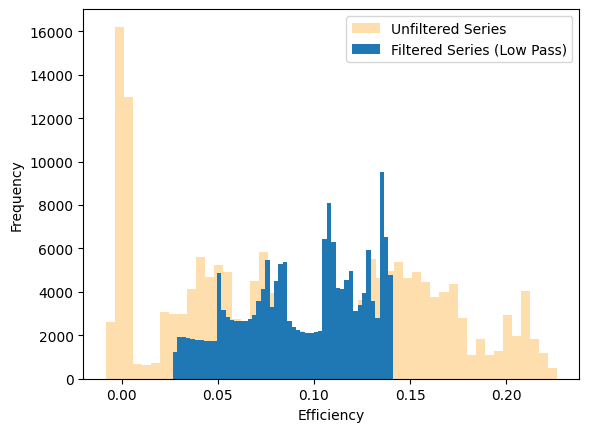

In [8]:
plt.hist((shifted_power_series[mask]/total_surface_area)/new_irradiance_series['ghi'][mask], bins = 50, label='Unfiltered Series', color='navajowhite')
plt.hist((filtered_power_series[mask] / total_surface_area) / new_irradiance_series['ghi'][mask], bins=50, label='Filtered Series (Low Pass)')

plt.legend()

plt.ylabel("Frequency")
plt.xlabel("Efficiency")

plt.show()

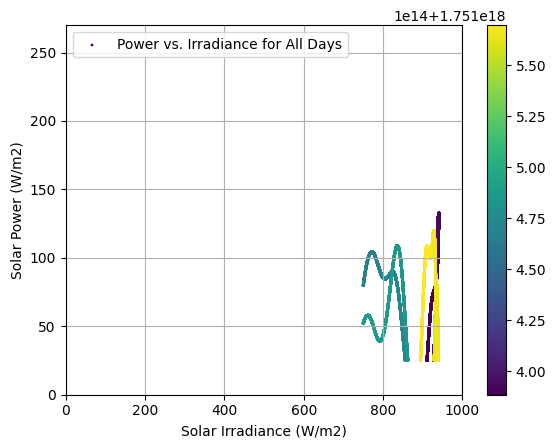

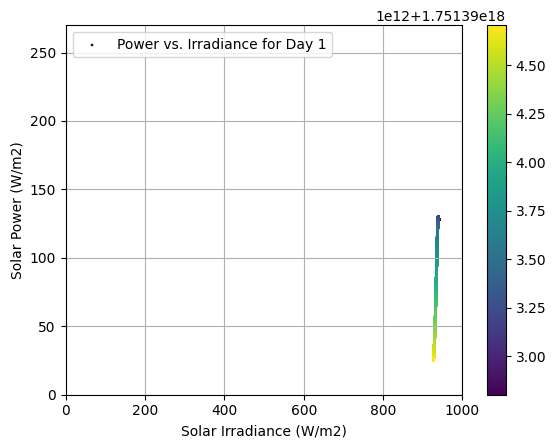

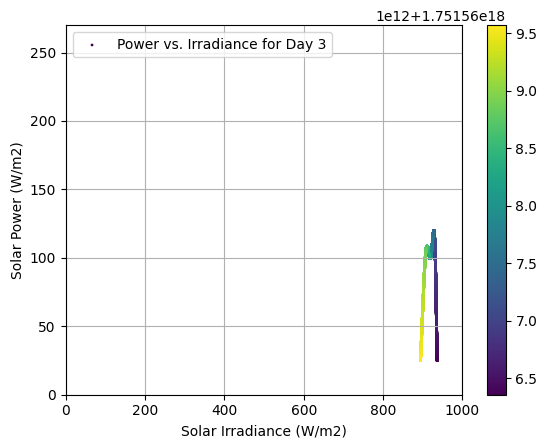

In [9]:
def showPlot(mask, label: str):
    plt.scatter(new_irradiance_series['ghi'][mask], (filtered_power_series[mask] / total_surface_area), s=1, c=date_time_x_axis[mask], label=f'Power vs. Irradiance for {label}')
    #plt.scatter(new_irradiance_series['ghi'][mask], new_irradiance_series['ghi'][mask]*average_efficiency_without_day_2, s=2, label='Average Efficiency (Excluding Day 2)')

    plt.colorbar()
    plt.xlim(0,1000)
    plt.ylim(0,270)

    plt.grid()
    plt.legend(loc = 'upper left')

    plt.ylabel("Solar Power (W/m2)")
    plt.xlabel("Solar Irradiance (W/m2)")

    plt.show()

showPlot(mask, 'All Days')
showPlot(mask1, 'Day 1')
showPlot(mask3, 'Day 3')
